<a href="https://colab.research.google.com/github/sathkumara-smna/258739K/blob/main/site_power_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [238]:
# Telecom Site Power Prediction – Hybrid Engineering + ML Model
## Google Colab Python Code

# ============================================================
# TELECOM SITE POWER PREDICTION
# HYBRID ENGINEERING + ML MODEL
# C&W SEYCHELLES
# ============================================================

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# ============================================================
# LOAD EXCEL FILES FROM GITHUB
# ============================================================

site_db_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/Site%20Database%20from%20Sey.xlsx"
site_power_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/site_power%20from%20Sey.xlsx"
traffic_4g_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/4G%20Traffic.xlsx"
traffic_5g_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/5G%20Traffic.xlsx"

# ============================================================
# READ FILES
# ============================================================

site_db = pd.read_excel(site_db_url)
site_power = pd.read_excel(site_power_url)
traffic_4g = pd.read_excel(traffic_4g_url)
traffic_5g = pd.read_excel(traffic_5g_url)

In [239]:
site_db.head(2)

,#,Site_ID,Site Name,2G RRUs,3G RRUs,4G RRUs,5G AAUs,2G Boards,3G Boards,4G Boards,5G Boards,BBU 5900,BBU 3900,BBU 3910
0,1,101,AIRPORT_MAHE,3,7,12,3,1,2,2,1,1,1,1
1,2,102,AIRPORT_PRASLIN,2,4,4,0,1,1,1,0,0,1,0


In [240]:
site_power.head(2)

,Site_ID,trigger_ID,date,datetime,site_power
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512


In [241]:
traffic_4g.head(2)

,Site_ID,Cell_ID,Sector_ID,trigger_ID,date,datetime,traffic_load_mbps
0,101,10111,11,1,2026-03-01,2026-03-01 00:00,11.90
1,101,10111,11,2,2026-03-01,2026-03-01 00:15,12.03


In [242]:
traffic_5g.head(2)

,Site_ID,Cell_ID,Sector_ID,trigger_ID,date,datetime,traffic_load_mbps
0,101,1011,1,1,2026-03-01,2026-03-01 00:00,61.20
1,101,1011,1,2,2026-03-01,2026-03-01 00:15,67.31


In [243]:
# ============================================================
# RENAME COLUMNS
# ============================================================

site_db.columns = [
    '#',
    'Site_ID',
    'Site_Name',
    'RRU_2G',
    'RRU_3G',
    'RRU_4G',
    'AAU_5G',
    'Col_H',
    'Col_I',
    'Boards_4G',
    'Boards_5G',
    'BBU5900',
    'BBU3900',
    'BBU3910'
]

In [244]:
# ============================================================
# AGGREGATE 4G TRAFFIC
# ============================================================

traffic_4g_summary = (

    traffic_4g.groupby(
        ["Site_ID", "trigger_ID", "date", "datetime"],
        as_index=False
    )["traffic_load_mbps"]

    .sum()

)

traffic_4g_summary.rename(
    columns={"traffic_load_mbps": "total_4g_traffic"},
    inplace=True
)
traffic_4g_summary.head(2)


,Site_ID,trigger_ID,date,datetime,total_4g_traffic
0,101,1,2026-03-01,2026-03-01 00:00,150.81
1,101,1,2026-03-02,2026-03-02 00:00,154.18


In [245]:
# ============================================================
# AGGREGATE 5G TRAFFIC
# ============================================================

traffic_5g_summary = (

    traffic_5g.groupby(
        ["Site_ID", "trigger_ID", "date", "datetime"],
        as_index=False
    )["traffic_load_mbps"]

    .sum()

)

traffic_5g_summary.rename(
    columns={"traffic_load_mbps": "total_5g_traffic"},
    inplace=True
)
traffic_5g_summary.head(2)


,Site_ID,trigger_ID,date,datetime,total_5g_traffic
0,101,1,2026-03-01,2026-03-01 00:00,172.34
1,101,1,2026-03-02,2026-03-02 00:00,234.09


In [246]:
# ============================================================
# MERGE DATASETS
# ============================================================

merged_df = site_power.merge(
    traffic_4g_summary,
    on=["Site_ID", "trigger_ID", "date", "datetime"],
    how="left"
)

merged_df = merged_df.merge(
    traffic_5g_summary,
    on=["Site_ID", "trigger_ID", "date", "datetime"],
    how="left"
)

merged_df = merged_df.merge(
    site_db,
    on="Site_ID",
    how="left"
)
merged_df.head(2)

,Site_ID,trigger_ID,date,datetime,site_power,total_4g_traffic,total_5g_traffic,#,Site_Name,RRU_2G,RRU_3G,RRU_4G,AAU_5G,Col_H,Col_I,Boards_4G,Boards_5G,BBU5900,BBU3900,BBU3910
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299,150.81,172.34,1,AIRPORT_MAHE,3,7,12,3,1,2,2,1,1,1,1
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512,155.48,188.49,1,AIRPORT_MAHE,3,7,12,3,1,2,2,1,1,1,1


In [247]:
# ============================================================
# FILL NOMINAL ENGINEERING INDUSTRY VALUES
# ============================================================

merged_df.fillna(0, inplace=True)

# ============================================================
# ENGINEERING POWER ASSUMPTIONS
# ============================================================

RRU_2G_POWER = 150
RRU_3G_POWER = 200
RRU_4G_POWER = 180
AAU_5G_POWER = 500

BBU3900_POWER = 55
BBU3910_POWER = 65
BBU5900_POWER = 75

BOARD_4G_POWER = 42.5
BOARD_5G_POWER = 80
merged_df.head(2)

,Site_ID,trigger_ID,date,datetime,site_power,total_4g_traffic,total_5g_traffic,#,Site_Name,RRU_2G,RRU_3G,RRU_4G,AAU_5G,Col_H,Col_I,Boards_4G,Boards_5G,BBU5900,BBU3900,BBU3910
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299,150.81,172.34,1,AIRPORT_MAHE,3,7,12,3,1,2,2,1,1,1,1
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512,155.48,188.49,1,AIRPORT_MAHE,3,7,12,3,1,2,2,1,1,1,1


In [248]:
# ============================================================
# STATIC POWER CALCULATIONS
# ============================================================

merged_df["power_2g"] = (
    merged_df["RRU_2G"] * RRU_2G_POWER
)

merged_df["power_3g"] = (
    merged_df["RRU_3G"] * RRU_3G_POWER
)

merged_df["power_4g_rru"] = (
    merged_df["RRU_4G"] * RRU_4G_POWER
)

merged_df["power_5g_aau"] = (
    merged_df["AAU_5G"] * AAU_5G_POWER
)

merged_df["power_bbu3900"] = (
    merged_df["BBU3900"] * BBU3900_POWER
)

merged_df["power_bbu3910"] = (
    merged_df["BBU3910"] * BBU3910_POWER
)

merged_df["power_bbu5900"] = (
    merged_df["BBU5900"] * BBU5900_POWER
)

merged_df["power_4g_boards"] = (
    merged_df["Boards_4G"] * BOARD_4G_POWER
)

merged_df["power_5g_boards"] = (
    merged_df["Boards_5G"] * BOARD_5G_POWER
)
merged_df.head(2)

,Site_ID,trigger_ID,date,datetime,site_power,total_4g_traffic,total_5g_traffic,#,Site_Name,RRU_2G,...,BBU3910,power_2g,power_3g,power_4g_rru,power_5g_aau,power_bbu3900,power_bbu3910,power_bbu5900,power_4g_boards,power_5g_boards
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299,150.81,172.34,1,AIRPORT_MAHE,3,...,1,450,1400,2160,1500,55,65,75,85.0,80
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512,155.48,188.49,1,AIRPORT_MAHE,3,...,1,450,1400,2160,1500,55,65,75,85.0,80


In [249]:
# ============================================================
# DYNAMIC TRAFFIC POWER
# ============================================================

merged_df["dynamic_4g_power"] = (
    merged_df["total_4g_traffic"] * 0.03
)

merged_df["dynamic_5g_power"] = (
    merged_df["total_5g_traffic"] * 0.04
)
merged_df.head(2)

,Site_ID,trigger_ID,date,datetime,site_power,total_4g_traffic,total_5g_traffic,#,Site_Name,RRU_2G,...,power_3g,power_4g_rru,power_5g_aau,power_bbu3900,power_bbu3910,power_bbu5900,power_4g_boards,power_5g_boards,dynamic_4g_power,dynamic_5g_power
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299,150.81,172.34,1,AIRPORT_MAHE,3,...,1400,2160,1500,55,65,75,85.0,80,4.5243,6.8936
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512,155.48,188.49,1,AIRPORT_MAHE,3,...,1400,2160,1500,55,65,75,85.0,80,4.6644,7.5396


In [250]:
# ============================================================
# ENGINEERING PREDICTED POWER
# ============================================================

merged_df["engineering_predicted_power"] = (

    merged_df["power_2g"] +
    merged_df["power_3g"] +
    merged_df["power_4g_rru"] +
    merged_df["power_5g_aau"] +
    merged_df["power_bbu3900"] +
    merged_df["power_bbu3910"] +
    merged_df["power_bbu5900"] +
    merged_df["power_4g_boards"] +
    merged_df["power_5g_boards"] +
    merged_df["dynamic_4g_power"] +
    merged_df["dynamic_5g_power"]

)
merged_df.head(2)

,Site_ID,trigger_ID,date,datetime,site_power,total_4g_traffic,total_5g_traffic,#,Site_Name,RRU_2G,...,power_4g_rru,power_5g_aau,power_bbu3900,power_bbu3910,power_bbu5900,power_4g_boards,power_5g_boards,dynamic_4g_power,dynamic_5g_power,engineering_predicted_power
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299,150.81,172.34,1,AIRPORT_MAHE,3,...,2160,1500,55,65,75,85.0,80,4.5243,6.8936,5881.4179
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512,155.48,188.49,1,AIRPORT_MAHE,3,...,2160,1500,55,65,75,85.0,80,4.6644,7.5396,5882.2040


In [251]:
# ============================================================
# RESIDUAL ERROR
# ============================================================

merged_df["residual_error"] = (
    merged_df["site_power"] -
    merged_df["engineering_predicted_power"]
)
merged_df.head(2)

,Site_ID,trigger_ID,date,datetime,site_power,total_4g_traffic,total_5g_traffic,#,Site_Name,RRU_2G,...,power_5g_aau,power_bbu3900,power_bbu3910,power_bbu5900,power_4g_boards,power_5g_boards,dynamic_4g_power,dynamic_5g_power,engineering_predicted_power,residual_error
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299,150.81,172.34,1,AIRPORT_MAHE,3,...,1500,55,65,75,85.0,80,4.5243,6.8936,5881.4179,636.2120
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512,155.48,188.49,1,AIRPORT_MAHE,3,...,1500,55,65,75,85.0,80,4.6644,7.5396,5882.2040,651.3472


In [252]:
# ============================================================
# MACHINE LEARNING FEATURES
# ============================================================

features = [

    "RRU_2G",
    "RRU_3G",
    "RRU_4G",
    "AAU_5G",
    "Boards_4G",
    "Boards_5G",
    "BBU3900",
    "BBU3910",
    "BBU5900",
    "total_4g_traffic",
    "total_5g_traffic",
    "engineering_predicted_power"

]
X = merged_df[features]
y = merged_df["residual_error"]
merged_df['Site_ID'].count()

np.int64(50400)

In [253]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [254]:
# ============================================================
# BASELINE MODEL
# ============================================================

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

In [255]:
# ============================================================
# IMPROVED MODEL
# ============================================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

In [256]:
# ============================================================
# FINAL PREDICTIONS
# ============================================================

engineering_test = merged_df.loc[
    X_test.index,
    "engineering_predicted_power"
]

final_predictions = (
    engineering_test + rf_predictions
)

actual_values = merged_df.loc[
    X_test.index,
    "site_power"
]
merged_df.head(2)
merged_df['Site_ID'].count()
print(merged_df.columns)

Index(['Site_ID', 'trigger_ID', 'date', 'datetime', 'site_power',
       'total_4g_traffic', 'total_5g_traffic', '#', 'Site_Name', 'RRU_2G',
       'RRU_3G', 'RRU_4G', 'AAU_5G', 'Col_H', 'Col_I', 'Boards_4G',
       'Boards_5G', 'BBU5900', 'BBU3900', 'BBU3910', 'power_2g', 'power_3g',
       'power_4g_rru', 'power_5g_aau', 'power_bbu3900', 'power_bbu3910',
       'power_bbu5900', 'power_4g_boards', 'power_5g_boards',
       'dynamic_4g_power', 'dynamic_5g_power', 'engineering_predicted_power',
       'residual_error'],
      dtype='object')


In [257]:
merged_df['error_percentage'] = (
    (merged_df['site_power'] - merged_df['engineering_predicted_power'])
    / merged_df['site_power']
) * 100
merged_df.head(2)

,Site_ID,trigger_ID,date,datetime,site_power,total_4g_traffic,total_5g_traffic,#,Site_Name,RRU_2G,...,power_bbu3900,power_bbu3910,power_bbu5900,power_4g_boards,power_5g_boards,dynamic_4g_power,dynamic_5g_power,engineering_predicted_power,residual_error,error_percentage
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299,150.81,172.34,1,AIRPORT_MAHE,3,...,55,65,75,85.0,80,4.5243,6.8936,5881.4179,636.2120,9.761401
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512,155.48,188.49,1,AIRPORT_MAHE,3,...,55,65,75,85.0,80,4.6644,7.5396,5882.2040,651.3472,9.969268


In [258]:
# ============================================================
# EVALUATION
# ============================================================

mae = mean_absolute_error(
    actual_values,
    final_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        actual_values,
        final_predictions
    )
)

mape = np.mean(
    np.abs(
        (actual_values - final_predictions)
        / actual_values
    )
) * 100

r2 = r2_score(
    actual_values,
    final_predictions
)
merged_df['Site_ID'].count()

np.int64(50400)

In [259]:
# ============================================================
# PRINT RESULTS
# ============================================================

print("================================")
print("MODEL PERFORMANCE")
print("================================")

print(f"MAE  : {round(mae, 2)}")
print(f"RMSE : {round(rmse, 2)}")
print(f"MAPE : {round(mape, 2)} %")
print(f"R2   : {round(r2, 4)}")
merged_df['Site_ID'].count()

MODEL PERFORMANCE
MAE  : 152.1
RMSE : 213.1
MAPE : 3.74 %
R2   : 0.9893


np.int64(50400)

In [260]:
# ============================================================
# EXPORT RESULTS
# ============================================================
columns_to_export = [
    'Site_ID',
    'trigger_ID',
    'date',
    'datetime',
    'site_power',
    'engineering_predicted_power',
    'residual_error'
]

merged_df[columns_to_export].to_excel(
    "Final_Site_Power_Predictions.xlsx",
    index=False
)

print("================================")
print("OUTPUT FILE CREATED")
print("================================")

print("Final_Site_Power_Predictions.xlsx")

OUTPUT FILE CREATED
Final_Site_Power_Predictions.xlsx


In [261]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({

    "Feature": features,
    "Importance": rf_model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("================================")
print("FEATURE IMPORTANCE")
print("================================")

print(importance_df)

FEATURE IMPORTANCE
                        Feature  Importance
10             total_5g_traffic    0.755270
9              total_4g_traffic    0.138859
11  engineering_predicted_power    0.088676
1                        RRU_3G    0.003841
5                     Boards_5G    0.003081
0                        RRU_2G    0.002820
2                        RRU_4G    0.002405
8                       BBU5900    0.002295
3                        AAU_5G    0.002007
4                     Boards_4G    0.000643
7                       BBU3910    0.000101
6                       BBU3900    0.000000


In [262]:
# ============================================================
# SAMPLE RESULTS
# ============================================================

print("================================")
print("SAMPLE PREDICTIONS")
print("================================")

print(merged_df.head(2))



SAMPLE PREDICTIONS
   Site_ID  trigger_ID        date          datetime  site_power  \
0      101           1  2026-03-01  2026-03-01 00:00   6517.6299   
1      101           2  2026-03-01  2026-03-01 00:15   6533.5512   

   total_4g_traffic  total_5g_traffic  #     Site_Name  RRU_2G  ...  \
0            150.81            172.34  1  AIRPORT_MAHE       3  ...   
1            155.48            188.49  1  AIRPORT_MAHE       3  ...   

   power_bbu3900  power_bbu3910  power_bbu5900  power_4g_boards  \
0             55             65             75             85.0   
1             55             65             75             85.0   

   power_5g_boards  dynamic_4g_power  dynamic_5g_power  \
0               80            4.5243            6.8936   
1               80            4.6644            7.5396   

   engineering_predicted_power  residual_error  error_percentage  
0                    5881.4179        636.2120          9.761401  
1                    5882.2040        651.3472     

In [263]:
# Get the row with maximum absolute residual_error for each Site_ID
summary_df = merged_df.loc[
    merged_df.groupby('Site_ID')['residual_error']
    .apply(lambda x: x.abs().idxmax())
]

# Keep only required columns
summary_df = summary_df[
    [
        'Site_ID',
        'engineering_predicted_power',
        'site_power',
        'residual_error',
        'error_percentage'
    ]
]

# Export to Excel
summary_df.to_excel(
    "Final_Site_Power_Predictions_Summary.xlsx",
    index=False
)

print("Summary file created successfully.")

Summary file created successfully.


In [264]:
print(merged_df.columns)

Index(['Site_ID', 'trigger_ID', 'date', 'datetime', 'site_power',
       'total_4g_traffic', 'total_5g_traffic', '#', 'Site_Name', 'RRU_2G',
       'RRU_3G', 'RRU_4G', 'AAU_5G', 'Col_H', 'Col_I', 'Boards_4G',
       'Boards_5G', 'BBU5900', 'BBU3900', 'BBU3910', 'power_2g', 'power_3g',
       'power_4g_rru', 'power_5g_aau', 'power_bbu3900', 'power_bbu3910',
       'power_bbu5900', 'power_4g_boards', 'power_5g_boards',
       'dynamic_4g_power', 'dynamic_5g_power', 'engineering_predicted_power',
       'residual_error', 'error_percentage'],
      dtype='object')


In [265]:
import matplotlib.pyplot as plt

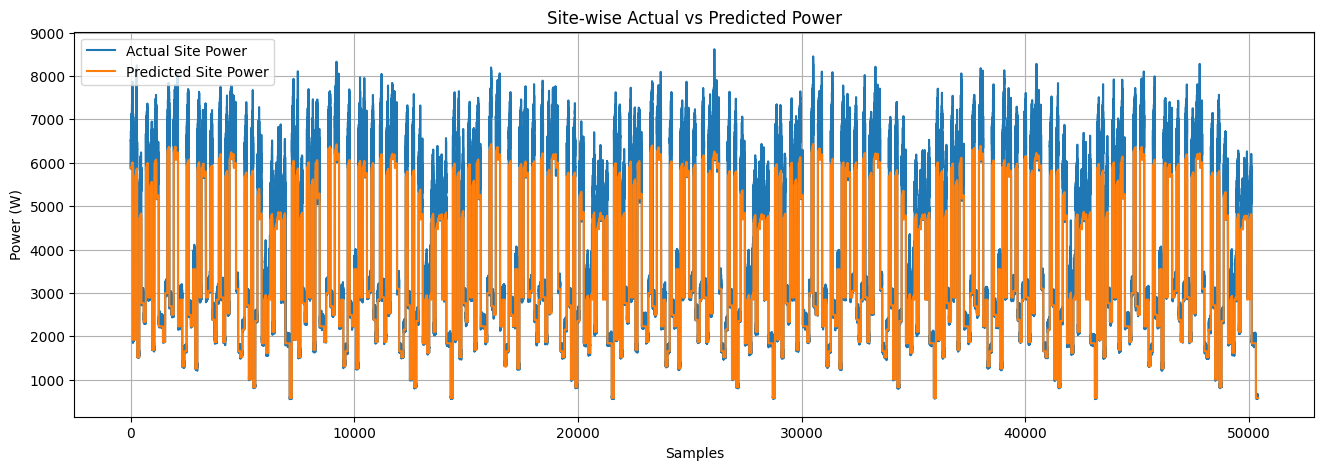

In [281]:
# ============================================
# 1. ACTUAL VS PREDICTED POWER GRAPH (LINE)
# ============================================


plt.figure(figsize=(16,5))
plt.plot(
    merged_df['site_power'],
    label='Actual Site Power'
)

plt.plot(
    merged_df['engineering_predicted_power'],
    label='Predicted Site Power'
)

plt.xlabel('Samples')
plt.ylabel('Power (W)')
plt.title('Site-wise Actual vs Predicted Power')
plt.legend()
plt.grid(True)
plt.show()

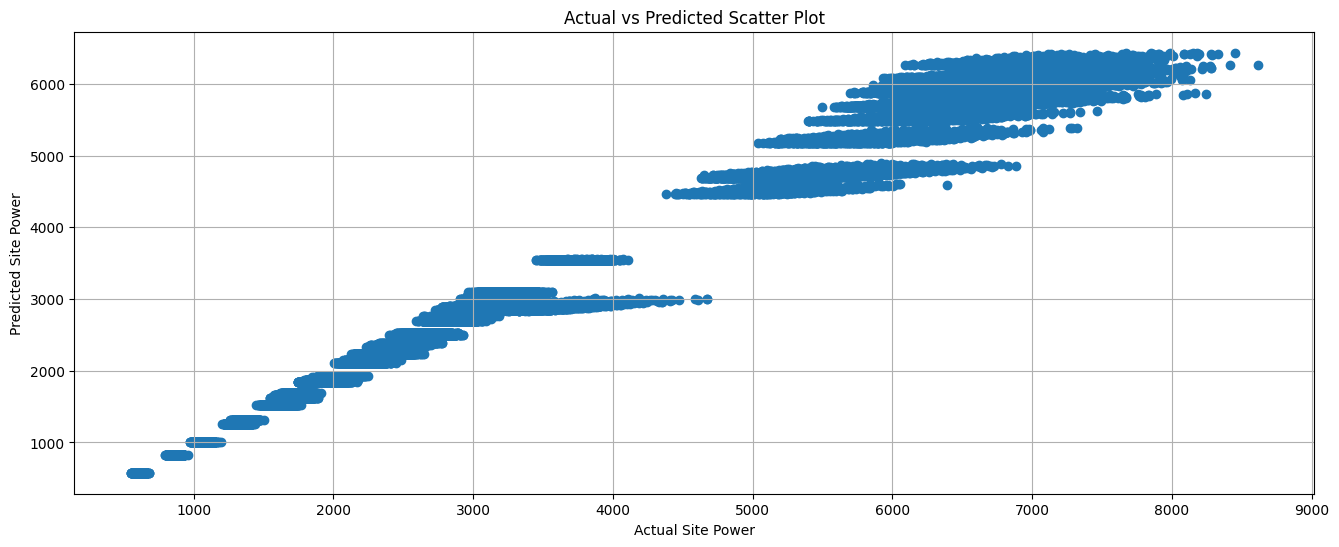

In [273]:
# ============================================================
# ACTUAL VS PREDICTED SCATTER PLOT
# ============================================================

plt.figure(figsize=(16,5))
plt.scatter(
    merged_df['site_power'],
    merged_df['engineering_predicted_power']
)

plt.xlabel('Actual Site Power')
plt.ylabel('Predicted Site Power')
plt.title('Actual vs Predicted Scatter Plot')
plt.grid(True)
plt.show()

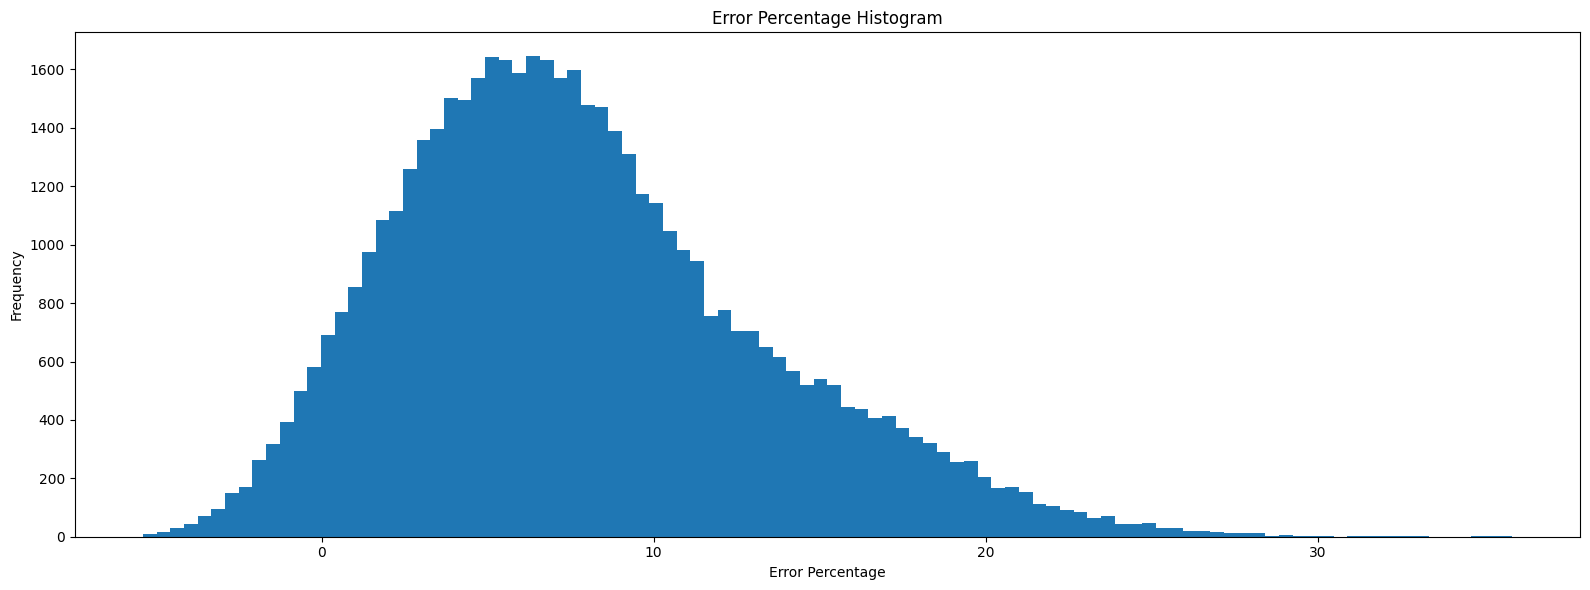

In [274]:
# ============================================
# 3. ERROR PERCENTAGE HISTOGRAM
# ============================================

plt.figure(figsize=(16,5))

plt.hist(
    merged_df['error_percentage'].dropna(),
    bins=100
)

plt.xlabel('Error Percentage')
plt.ylabel('Frequency')
plt.title('Error Percentage Histogram')
plt.tight_layout()
plt.show()

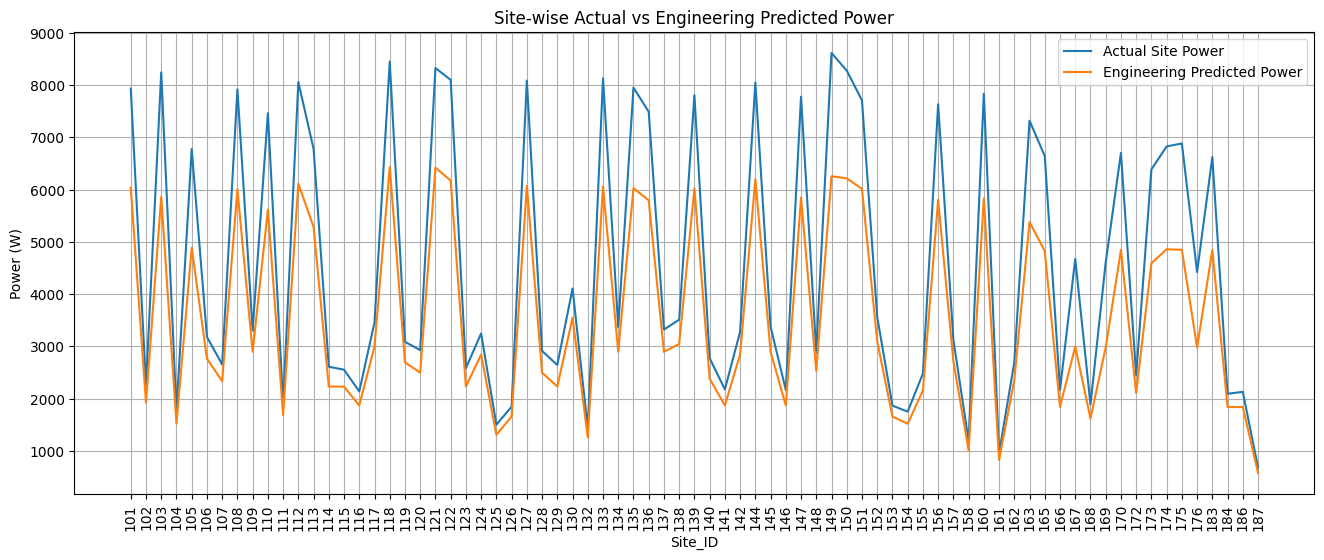

In [275]:
# ============================================================
# 1. SITE-WISE ACTUAL VS ENGINEERING PREDICTED POWER
# SORTED BY SITE_ID
# ============================================================

summary_df_site_sorted = summary_df.sort_values(by='Site_ID',ascending=True)
plt.figure(figsize=(16,5))

plt.plot(
    summary_df_site_sorted['Site_ID'].astype(str),
    summary_df_site_sorted['site_power'],
    label='Actual Site Power'
)

plt.plot(
    summary_df_site_sorted['Site_ID'].astype(str),
    summary_df_site_sorted['engineering_predicted_power'],
    label='Engineering Predicted Power'
)

plt.xlabel('Site_ID')
plt.ylabel('Power (W)')
plt.title('Site-wise Actual vs Engineering Predicted Power')
plt.xticks(rotation=90)
plt.legend()
plt.grid(True)
plt.show()

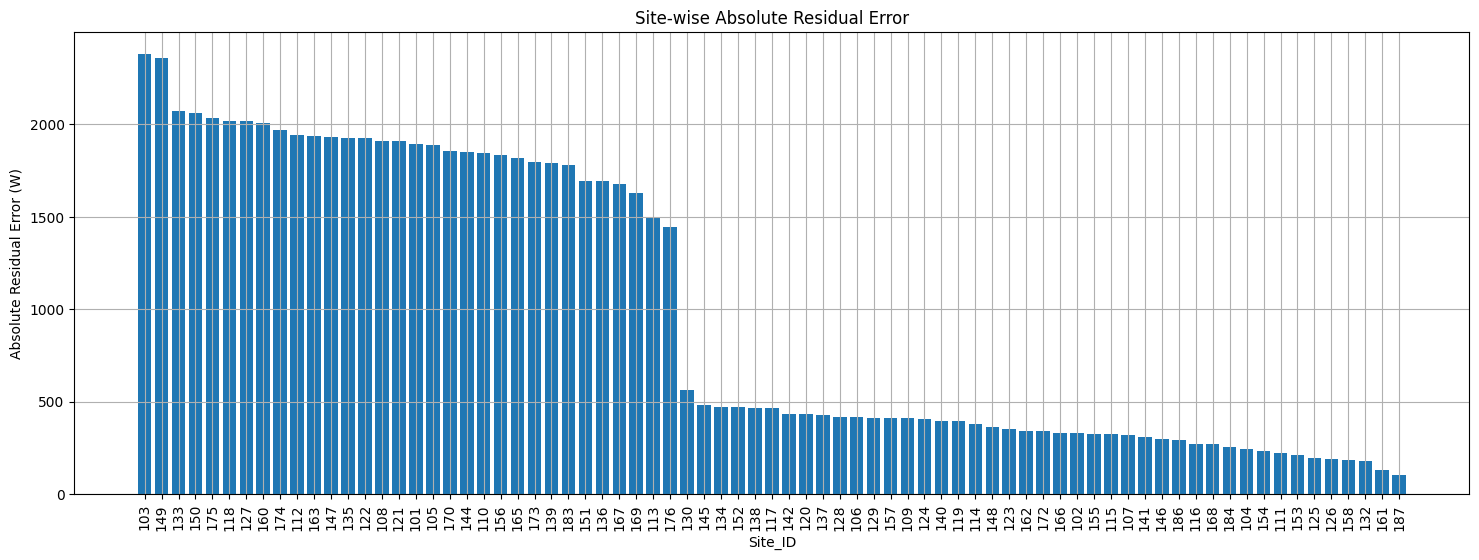

In [276]:
# ============================================================
# 2. ABSOLUTE RESIDUAL ERROR SITE-WISE
# SORTED FROM MAXIMUM TO MINIMUM
# ============================================================

summary_df['absolute_residual_error'] = (abs(summary_df['residual_error']))

summary_df_abs_sorted = summary_df.sort_values(
    by='absolute_residual_error',ascending=False
)

plt.figure(figsize=(16,5))
plt.bar(
    summary_df_abs_sorted['Site_ID'].astype(str),
    summary_df_abs_sorted['absolute_residual_error']
)

plt.xlabel('Site_ID')
plt.ylabel('Absolute Residual Error (W)')
plt.title('Site-wise Absolute Residual Error')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

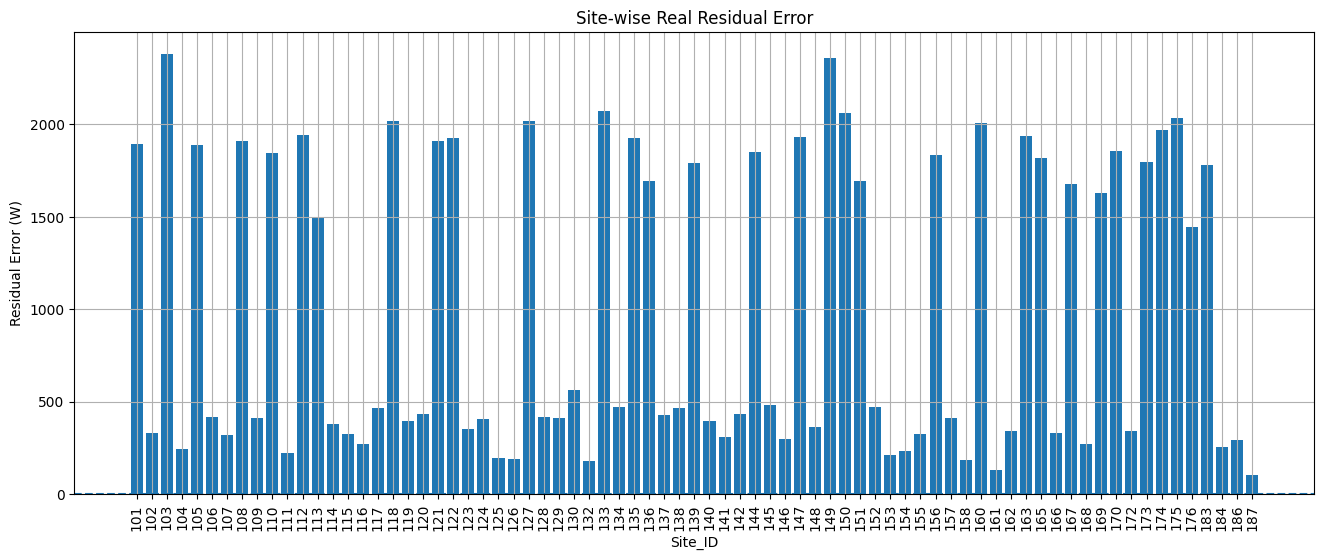

In [277]:
# ============================================================
# 3. REAL RESIDUAL ERROR SITE-WISE
# SORTED BY SITE_ID
# ============================================================

summary_df_real_sorted = summary_df.sort_values(by='Site_ID',ascending=True)
plt.figure(figsize=(16,5))
plt.bar(
    summary_df_real_sorted['Site_ID'].astype(str),
    summary_df_real_sorted['residual_error']
)

# Zero reference line
plt.axhline(y=0,linestyle='--')

plt.xlabel('Site_ID')
plt.ylabel('Residual Error (W)')
plt.title('Site-wise Real Residual Error')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()